# Imports

In [1]:
!pip install numpy matplotlib control

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import os

# Sistema

## Definición de la planta

In [3]:
os.makedirs("figuras", exist_ok=True) # Para guardar todas las figuras en una sola carpeta

K     = 1.0   # Ganancia
J     = 1.0   # Momento de inercia
B_nom  = 0.5  # Coeficiente de fricción nominal
B_fail = -0.1 # Coeficiente de fricción con falla


def make_plant(B):
    """Función de transferencia de la planta G(s) = K/(s*(J*s+B))"""
    return ctrl.tf([K], [J, B, 0])


def make_cl(G, C=None):
    """Sistema en lazo cerrado con realimentación unitaria."""
    if C is None:
        C = ctrl.tf([1], [1])
    return ctrl.feedback(C * G, 1)

## Parte A

### Inciso a

/usr/local/lib/python3.12/dist-packages/control/freqplot.py:1864: FutureWarning: nyquist_plot() return value of count[, contour] is deprecated; use nyquist_response()
  warnings.warn(


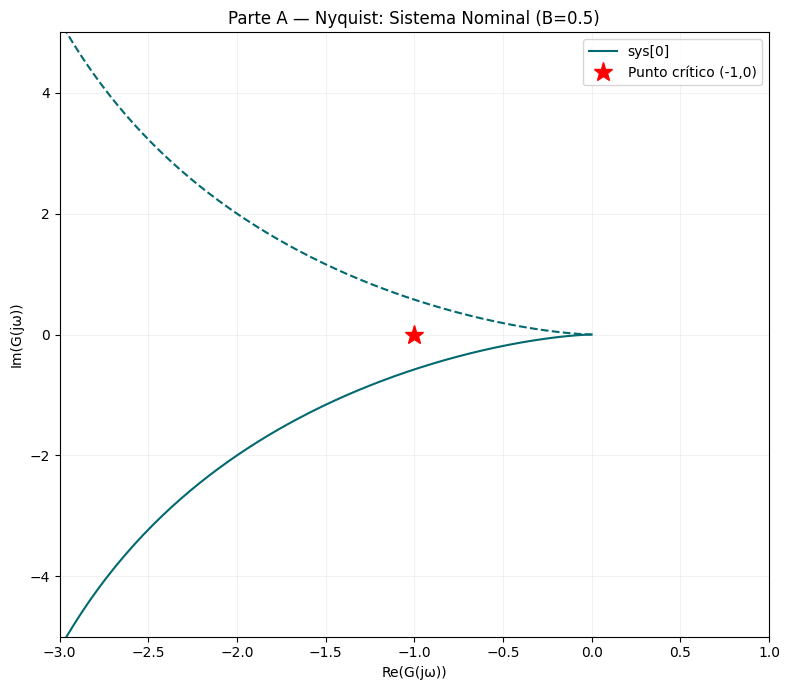

PARTE A — Inciso a)
  Polos de G(s) en lazo abierto: [-0.5+0.j  0. +0.j]
  Margen de Ganancia: inf (inf dB)
  Margen de Fase: 28.02°
  → P=0 (sin polos en RHP), N=0 (sin encerramiento de -1+j0)
  → Z = N + P = 0  →  Sistema ESTABLE en lazo cerrado


In [4]:
G_nom = make_plant(B_nom)

fig, ax = plt.subplots(figsize=(8, 7))
_ = ctrl.nyquist_plot(G_nom, plot=True, ax=ax, color="#01696f")
ax.plot(-1, 0, "r*", markersize=14, zorder=5, label="Punto crítico (-1,0)")
ax.set_title("Parte A — Nyquist: Sistema Nominal (B=0.5)")
ax.set_xlabel("Re(G(jω))")
ax.set_ylabel("Im(G(jω))")
ax.set_xlim([-3, 1])
ax.set_ylim([-5, 5])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figuras/A_a_nyquist_nominal.png", dpi=150)
plt.show()
plt.close()

# Análisis de estabilidad por Nyquist
poles_ol = ctrl.poles(G_nom)
gm, pm, wg, wp = ctrl.margin(G_nom)
print("=" * 60)
print("PARTE A — Inciso a)")
print(f"  Polos de G(s) en lazo abierto: {poles_ol}")
print(f"  Margen de Ganancia: {gm:.3f} ({20*np.log10(gm):.2f} dB)")
print(f"  Margen de Fase: {pm:.2f}°")
print("  → P=0 (sin polos en RHP), N=0 (sin encerramiento de -1+j0)")
print("  → Z = N + P = 0  →  Sistema ESTABLE en lazo cerrado")

### Inciso b

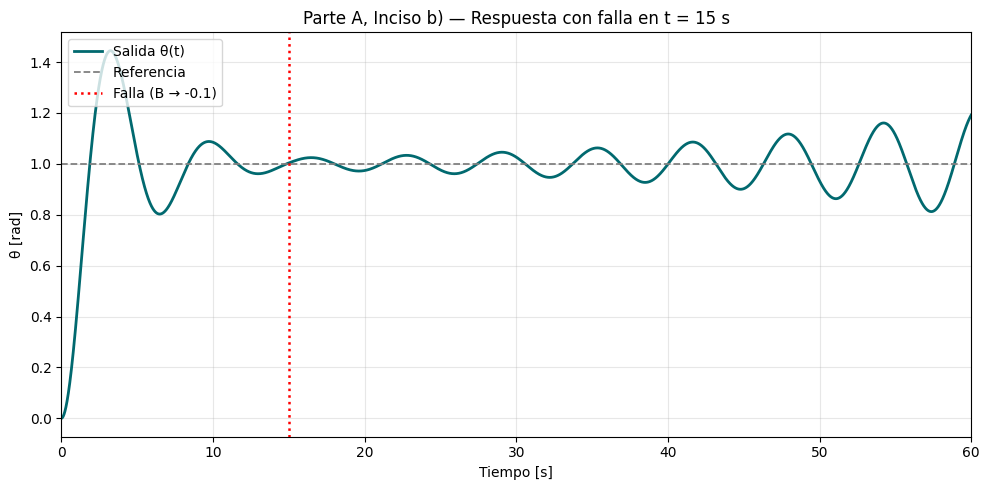


PARTE A — Inciso b)
  Polos del LC con falla: [0.05+0.99874922j 0.05-0.99874922j]
  Sistema con falla: INESTABLE


In [5]:
G_fail = make_plant(B_fail)
CL_nom_ss  = ctrl.ss(make_cl(G_nom))
CL_fail_ss = ctrl.ss(make_cl(G_fail))

dt  = 0.005
t1  = np.arange(0, 15 + dt, dt)
t2r = np.arange(0, 45 + dt, dt)   # relativo desde t=15

# Tramo 1: sistema nominal (0 a 15 s)
_, y1, xout = ctrl.forced_response(
    CL_nom_ss, T=t1, U=np.ones_like(t1),
    X0=np.zeros(CL_nom_ss.nstates), return_x=True
)
x0_at_15 = xout[:, -1]  # estado inicial para la falla

# Tramo 2: sistema con falla (15 s en adelante)
_, y2 = ctrl.forced_response(
    CL_fail_ss, T=t2r, U=np.ones_like(t2r), X0=x0_at_15
)

t_full = np.concatenate([t1, t2r[1:] + 15])
y_full = np.concatenate([y1, y2[1:]])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_full, y_full, color="#01696f", linewidth=2, label="Salida θ(t)")
ax.axhline(1, color="gray", linestyle="--", linewidth=1.3, label="Referencia")
ax.axvline(15, color="red", linestyle=":", linewidth=1.8, label="Falla (B → -0.1)")
ax.set_title("Parte A, Inciso b) — Respuesta con falla en t = 15 s")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("θ [rad]")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 60])
plt.tight_layout()
plt.savefig("figuras/A_b_respuesta_falla.png", dpi=150)
plt.show()
plt.close()

poles_cl_fail = ctrl.poles(make_cl(G_fail))
print("\n" + "=" * 60)
print("PARTE A — Inciso b)")
print(f"  Polos del LC con falla: {poles_cl_fail}")
inestable = any(p.real > 0 for p in poles_cl_fail)
print(f"  Sistema con falla: {'INESTABLE' if inestable else 'ESTABLE'}")

### Inciso c

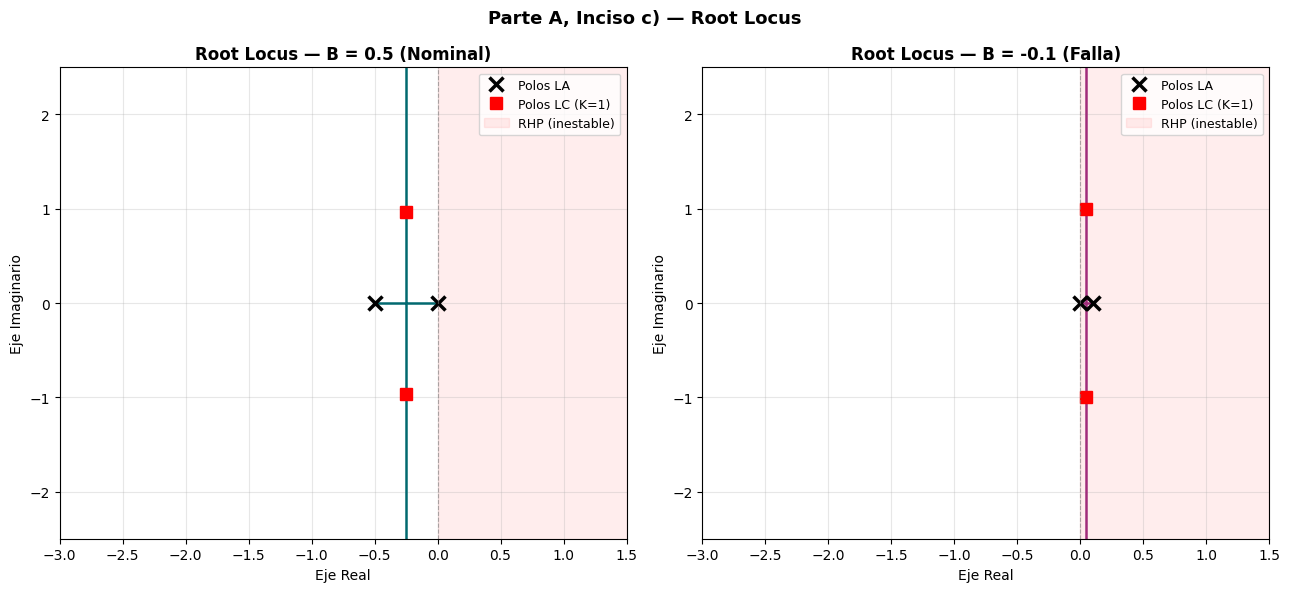

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
casos = [(G_nom, B_nom, "#01696f", "Nominal"), (G_fail, B_fail, "#a12c7b", "Falla")]

for ax, (G, B, col, lbl) in zip(axes, casos):
    rlocus_data = ctrl.root_locus_map(G)
    rlist = rlocus_data.loci

    for branch in rlist.T:
        ax.plot(branch.real, branch.imag, color=col, linewidth=1.8)
        #ax.plot(branch.real, -branch.imag, color=col, linewidth=1.8)

    poles_ol = ctrl.poles(G)
    poles_cl = ctrl.poles(make_cl(G))

    ax.plot(poles_ol.real, poles_ol.imag, "kx", markersize=10, markeredgewidth=2.5,
            label="Polos LA")
    ax.plot(poles_cl.real, poles_cl.imag, "rs", markersize=8, label="Polos LC (K=1)")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.fill_betweenx([-3, 3], 0, 1.5, alpha=0.07, color="red", label="RHP (inestable)")
    ax.set_title(f"Root Locus — B = {B} ({lbl})", fontweight="bold")
    ax.set_xlabel("Eje Real")
    ax.set_ylabel("Eje Imaginario")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-3, 1.5])
    ax.set_ylim([-2.5, 2.5])

plt.suptitle("Parte A, Inciso c) — Root Locus", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figuras/A_c_root_locus.png", dpi=150)
plt.show()
plt.close()

### Inciso d

Uso un compensador Lead

## Parte B

In [7]:
def design_lead(G, target_PM_deg, extra_margin=8):
    """
    Diseña compensador lead: C(s) = (1 + alpha*T*s) / (1 + T*s)
    - phi_m = fase adicional necesaria
    - alpha determinado por phi_m
    - T elegido para que la freq. de máx. fase coincida con el nuevo cruce de 0 dB
    - Ganancia DC normalizada a 1
    """
    _, pm_current, _, _ = ctrl.margin(G)
    phi_m = np.radians(target_PM_deg - pm_current + extra_margin)
    alpha = (1 + np.sin(phi_m)) / (1 - np.sin(phi_m))

    omega_range = np.logspace(-2, 2, 10000)
    mag, phase, omega = ctrl.frequency_response(G, omega_range)
    # Nueva frec. de cruce: donde |G| = 1/sqrt(alpha)
    idx   = np.argmin(np.abs(mag - 1.0 / np.sqrt(alpha)))
    w_max = omega_range[idx]
    T     = 1.0 / (w_max * np.sqrt(alpha))

    # C(s) = (alpha*T*s + 1) / (T*s + 1)  — ganancia DC = 1
    C = ctrl.tf([alpha * T, 1], [T, 1])
    return C, alpha, T, w_max


target_MFs  = [35, 50, 65]
colors_comp = ["#006494", "#da7101", "#437a22"]
compensators = {}

print("\n" + "=" * 60)
print("PARTE B — Compensadores Lead Diseñados:")
for mf in target_MFs:
    C, alpha, T, wc = design_lead(G_nom, mf)
    _, pm_real, _, _ = ctrl.margin(C * G_nom)
    compensators[mf] = {"C": C, "alpha": alpha, "T": T, "wc": wc, "pm": pm_real}
    print(f"  MF={mf}°: α={alpha:.3f}, T={T:.4f} s, wc={wc:.3f} rad/s "
          f"| MF obtenido={pm_real:.1f}°")
    print(f"    C(s) = ({alpha*T:.4f}·s + 1) / ({T:.4f}·s + 1)")



PARTE B — Compensadores Lead Diseñados:
  MF=35°: α=1.697, T=0.7056 s, wc=1.088 rad/s | MF obtenido=39.7°
    C(s) = (1.1975·s + 1) / (0.7056·s + 1)
  MF=50°: α=2.998, T=0.4552 s, wc=1.269 rad/s | MF obtenido=51.5°
    C(s) = (1.3645·s + 1) / (0.4552·s + 1)
  MF=65°: α=5.823, T=0.2737 s, wc=1.514 rad/s | MF obtenido=63.3°
    C(s) = (1.5935·s + 1) / (0.2737·s + 1)


### Inciso b

/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


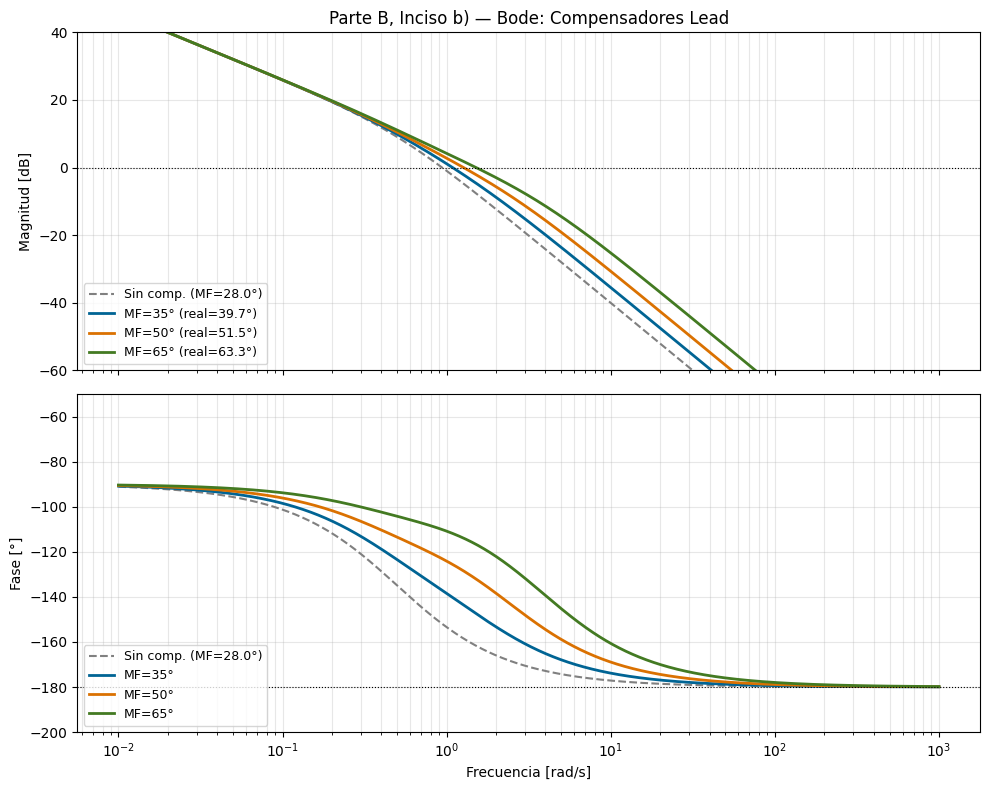

In [8]:
omega = np.logspace(-2, 3, 2000)
fig, (ax_m, ax_p) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

mag0, ph0, _ = ctrl.bode(G_nom, omega=omega, plot=False)
_, pm0, _, _  = ctrl.margin(G_nom)
ax_m.semilogx(omega, 20*np.log10(mag0), "--", color="gray", lw=1.5,
               label=f"Sin comp. (MF={pm0:.1f}°)")
ax_p.semilogx(omega, np.degrees(ph0), "--", color="gray", lw=1.5,
               label=f"Sin comp. (MF={pm0:.1f}°)")

for mf, col in zip(target_MFs, colors_comp):
    C  = compensators[mf]["C"]
    pm = compensators[mf]["pm"]
    mag, ph, _ = ctrl.bode(C * G_nom, omega=omega, plot=False)
    ax_m.semilogx(omega, 20*np.log10(mag), lw=2, color=col,
                   label=f"MF={mf}° (real={pm:.1f}°)")
    ax_p.semilogx(omega, np.degrees(ph), lw=2, color=col, label=f"MF={mf}°")

ax_m.axhline(0, color="k", lw=0.8, ls=":")
ax_m.set_ylabel("Magnitud [dB]")
ax_m.set_title("Parte B, Inciso b) — Bode: Compensadores Lead")
ax_m.legend(loc="lower left", fontsize=9)
ax_m.grid(True, which="both", alpha=0.3)
ax_m.set_ylim([-60, 40])

ax_p.axhline(-180, color="k", lw=0.8, ls=":")
ax_p.set_ylabel("Fase [°]")
ax_p.set_xlabel("Frecuencia [rad/s]")
ax_p.legend(loc="lower left", fontsize=9)
ax_p.grid(True, which="both", alpha=0.3)
ax_p.set_ylim([-200, -50])

plt.tight_layout()
plt.savefig("figuras/B_b_bode_compensado.png", dpi=150)
plt.show()
plt.close()

### Inciso c


PARTE B — Inciso c): Tiempos de establecimiento con falla:
  MF=35° (real=39.7°): ts(2%) = 6.9 s
  MF=50° (real=51.5°): ts(2%) = 3.9 s
  MF=65° (real=63.3°): ts(2%) = 3.3 s


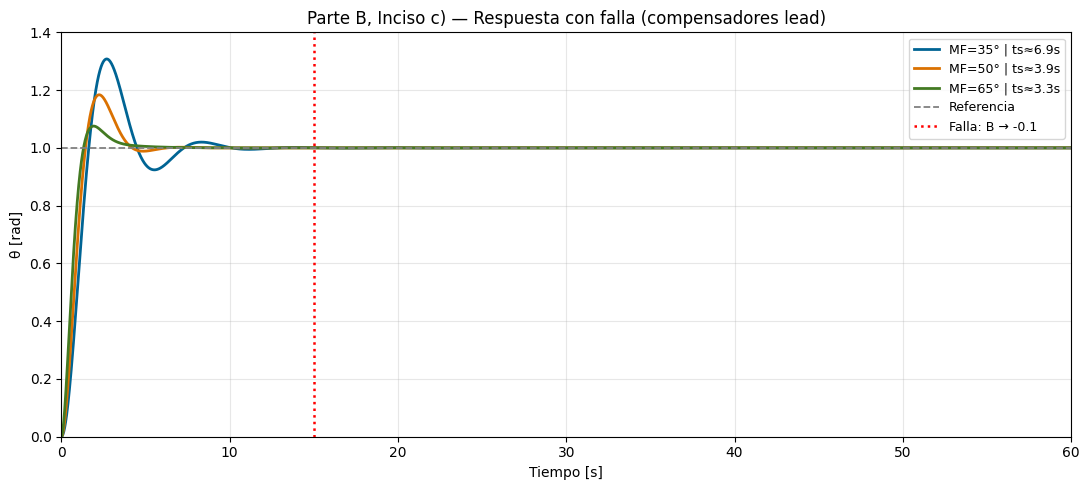

In [16]:
def ts_2pct(t, y, ref=1.0):
    """Tiempo de establecimiento al 2%."""
    tol = 0.02 * ref
    settled = np.where(np.abs(y - ref) > tol)[0]
    return t[settled[-1]] if len(settled) > 0 else 0.0


fig, ax = plt.subplots(figsize=(11, 5))
print("\n" + "=" * 60)
print("PARTE B — Inciso c): Tiempos de establecimiento con falla:")
for mf, col in zip(target_MFs, colors_comp):
    C = compensators[mf]["C"]
    SS_nom_c  = ctrl.ss(make_cl(G_nom, C))
    SS_fail_c = ctrl.ss(make_cl(G_fail, C))

    _, y1, xout = ctrl.forced_response(
        SS_nom_c, T=t1, U=np.ones_like(t1),
        X0=np.zeros(SS_nom_c.nstates), return_x=True
    )
    _, y2 = ctrl.forced_response(
        SS_fail_c, T=t2r, U=np.ones_like(t2r), X0=xout[:, -1]
    )
    t_f = np.concatenate([t1, t2r[1:] + 15])
    y_f = np.concatenate([y1, y2[1:]])

    ts = ts_2pct(t_f, y_f)
    pm = compensators[mf]["pm"]
    print(f"  MF={mf}° (real={pm:.1f}°): ts(2%) = {ts:.1f} s")
    ax.plot(t_f, y_f, color=col, lw=2, label=f"MF={mf}° | ts≈{ts:.1f}s")

ax.axhline(1, color="gray", ls="--", lw=1.3, label="Referencia")
ax.axvline(15, color="red", ls=":", lw=1.8, label="Falla: B → -0.1")
ax.set_title("Parte B, Inciso c) — Respuesta con falla (compensadores lead)")
ax.set_xlabel("Tiempo [s]")
ax.set_ylabel("θ [rad]")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 60])
ax.set_ylim([0, 1.4])
plt.tight_layout()
plt.savefig("figuras/B_c_respuesta_compensada_falla.png", dpi=150)
plt.show()
plt.close()

### Inciso d

/usr/local/lib/python3.12/dist-packages/control/freqplot.py:1509: UserWarning: number of encirclements was a non-integer value; this can happen is contour is not closed, possibly based on a frequency range that does not include zero.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/control/freqplot.py:1852: UserWarning: number of encirclements does not match Nyquist criterion; check frequency range and indent radius/direction
  nyquist_responses = nyquist_response(


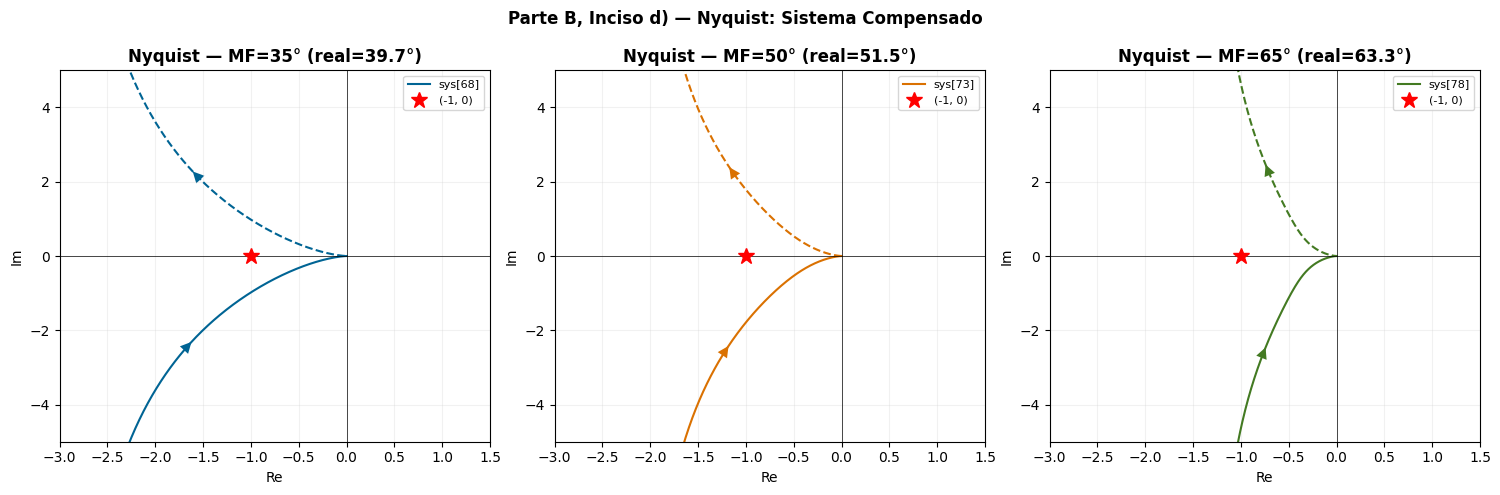

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, mf, col in zip(axes, target_MFs, colors_comp):
    C  = compensators[mf]["C"]
    pm = compensators[mf]["pm"]
    ctrl.nyquist_plot(C * G_nom, omega_limits=[1e-2, 1e2], plot=True,
                         ax=ax, color=col)
    ax.plot(-1, 0, "r*", markersize=12, zorder=5, label="(-1, 0)")
    ax.set_title(f"Nyquist — MF={mf}° (real={pm:.1f}°)", fontweight="bold")
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    ax.set_xlim([-3, 1.5])
    ax.set_ylim([-5, 5])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(0, color="k", lw=0.5)

plt.suptitle("Parte B, Inciso d) — Nyquist: Sistema Compensado", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figuras/B_d_nyquist_compensado.png", dpi=150)
plt.show()
plt.close()